In [362]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [363]:
repo_folder = Path("../..")
gp_folder = repo_folder / "data" / "1_growth_phenotyping"
figure_folder = repo_folder / "Figures" / "1_growth_phenotyping"
figure_folder.mkdir(parents=True, exist_ok=True)

In [364]:
# Auxotrophy fn
fn_aa_screen_ml_1_od = gp_folder / "experimental_data" / "Ml" / "230306_auxotrophy_screen_1_Ml_OD.csv"
fn_aa_screen_ml_1_cfu = gp_folder / "experimental_data" / "Ml" / "230306_auxotrophy_screen_1_Ml_cfu.csv"
fn_aa_dropout_ml_od = gp_folder / "experimental_data" / "Ml" / "230316_AA_dropout_Ml_od600.csv"
fn_aa_dropout_ml_cfu = gp_folder / "experimental_data" / "Ml" / "230316_AA_dropout_Ml_cfu.csv"
fn_ml_oa_1 = gp_folder / "experimental_data" / "oa_ml_auxotrophy_vitamin_screen.csv"


In [365]:
# CS growth phenotyping fn
fn_gp_at = gp_folder / "experimental_data" / "At"/ "230525_growth_phenotyping_At.txt"
fn_gp_ct = gp_folder / "experimental_data" / "Ct"/ "230526_growth_phenotyping_ct.txt"
fn_gp_ml = gp_folder / "experimental_data" / "Ml"/ "230530_growth_phenotyping_Ml.txt"
fn_gp_oa = gp_folder / "experimental_data" / "Oa"/ "230526_growth_phenotyping_2_oa.txt"

fn_pyr_cit = gp_folder / "experimental_data" / "at_ct_ml_oa_pyruvate_citrate_od_long_table.csv"

# Plot Ml auxotrophy screen 

In [366]:
df_aa_screen_ml_1_od = pd.read_csv(fn_aa_screen_ml_1_od)
df_aa_screen_ml_1_cfu = pd.read_csv(fn_aa_screen_ml_1_cfu)


In [367]:
# drop negative control rows
df_aa_screen_ml_1_od = df_aa_screen_ml_1_od.loc[~df_aa_screen_ml_1_od.Medium.str.contains('without Ms'), :]

In [368]:
df_aa_screen_ml_1_od.Medium = df_aa_screen_ml_1_od.Medium.str.replace(' (negative control)', '').str.replace(' (positive control)', '').str.replace(' 15 mM', '')
df_aa_screen_ml_1_od.Medium = df_aa_screen_ml_1_od.Medium.str.replace('AA', 'AAs').str.replace('Vitamins', 'vitamins')


In [369]:
# Only plot glucose condition
df_aa_screen_ml_1_od_glc = df_aa_screen_ml_1_od.loc[~df_aa_screen_ml_1_od.Medium.str.contains('glutamic acid'),:].copy()

In [370]:
medium_rename_dict = {1:'Glucose',
                      2:'Glucose + AAs',
                      3:'Glucose + vitamins',
                      4:'Glucose + AAs + vitamins',
                      11:'TSB'}

df_aa_screen_ml_1_od_glc.Medium = df_aa_screen_ml_1_od_glc['Medium no. '].map(medium_rename_dict)

In [371]:
n_reps = df_aa_screen_ml_1_od_glc.loc[df_aa_screen_ml_1_od_glc.Hours==0, :].groupby('Medium').size().mean()
print(f'Number of replicates: {n_reps}')


Number of replicates: 2.0


In [372]:
dashes_dict = defaultdict(tuple)
dashes_dict['Glucose + vitamins'] = (2, 2)
dashes_dict = {
    'Glucose': '',
    'Glucose + AAs': '',
    'Glucose + vitamins': '--',  # dashed
    'Glucose + AAs + vitamins': '',
    'TSB': ''
}

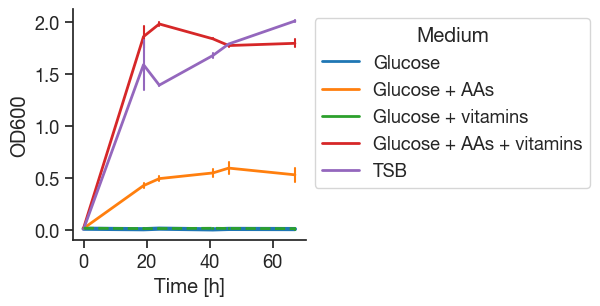

In [373]:
fig, ax = plt.subplots(1, figsize = (3, 3))
sns.lineplot(data = df_aa_screen_ml_1_od_glc, x = 'Hours', y = 'OD600', hue = 'Medium', ax = ax, errorbar= ('sd', 1), err_style='bars',
             palette='tab10', lw = 2, alpha = 1)
ax.lines[4].set_linestyle('--')
ax.lines[4].set_zorder(10)
ax.lines[4].set_linewidth(2)
ax.lines[0].set_linewidth(3)



# ax = sns.lineplot(data = df_aa_screen_ml_1_od_glc, x = 'Hours', y = 'OD600', hue = 'Medium', units="Sample ID",
#                   estimator=None, lw=1, marker = 'o', ms = 5)
# plt.yscale('log')
# sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=2)#, title=None, frameon=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), ncol=1)#, title=None, frameon=False)
# plt.tight_layout()
sns.despine()
# plt.subplots_adjust(right=0.8)

plt.xlabel('Time [h]')
plt.ylabel('OD600')
plt.savefig(figure_folder / "1A_ml_first_auxotrophy_screen.pdf", bbox_inches='tight')

## AA dropout Ml

In [374]:
df_AA_dropout_ml_od = pd.read_csv(fn_aa_dropout_ml_od)
df_AA_dropout_ml_od = df_AA_dropout_ml_od.loc[~df_AA_dropout_ml_od.Medium.str.contains('BLANK'), :]

In [375]:
n_reps = df_AA_dropout_ml_od.loc[df_AA_dropout_ml_od.Hours==0, :].groupby('Medium').size().mean()
print(f'Number of replicates: {n_reps}')


Number of replicates: 2.0


In [376]:
df_AA_dropout_ml_od.replace({'Medium': {'No AA':'No AAs',
                                    'all AA':'All AAs',
                                    'Δcys': 'Δ Cysteine',
                                    'Δpro': 'Δ Proline'}}, inplace = True)

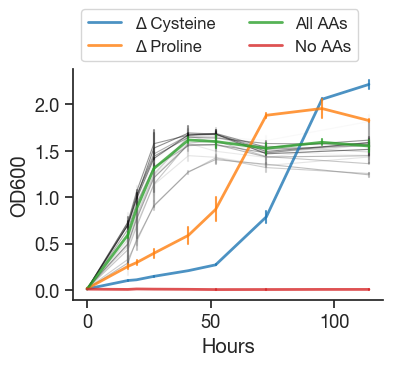

In [402]:
fig, ax = plt.subplots(1, figsize = (4, 3))
selected_media = ['No AAs', 'All AAs', 'Δ Cysteine', 'Δ Proline']
idx = df_AA_dropout_ml_od.Medium.isin(selected_media)
ax = sns.lineplot(data = df_AA_dropout_ml_od.loc[~idx], x = 'Hours', y = 'OD600', hue = 'Medium', errorbar= ('sd', 1), err_style='bars',
                ax = ax, palette = 'Grays', legend = False, lw = 0.8, alpha = 0.5)
ax = sns.lineplot(data = df_AA_dropout_ml_od.loc[idx], x = 'Hours', y = 'OD600', hue = 'Medium', errorbar= ('sd', 1), err_style='bars',
                ax = ax, palette = 'tab10', legend = True, lw = 2, alpha = 0.8)
#ax = sns.lineplot(data = od_no_ctr, x = 'Hours', y = 'OD600', hue = 'Medium', estimator=None, lw=1)

# plt.yscale('log')
# sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=2)#, title=None, frameon=False)
sns.move_legend(ax, "lower left", bbox_to_anchor=(0, 1), ncol=2, fontsize = 12, title = None)#, title=None, frameon=False)
# plt.tight_layout()
# plt.subplots_adjust(right=0.8)
sns.despine()
# plt.savefig('OD_with_sd.svg')

## Ml AA and vitamin

In [407]:
df_Ml_Oa_vitamins_OD = pd.read_csv(fn_ml_oa_1, index_col=0)



In [408]:

df_Ml_Oa_vitamins_OD.columns = [x.rstrip(' ') for x in df_Ml_Oa_vitamins_OD.columns]
df_Ml_Oa_vitamins_OD.Species = df_Ml_Oa_vitamins_OD.Species.str.replace('Ms', 'Ml')
df_Ml_Oa_vitamins_OD.Medium = df_Ml_Oa_vitamins_OD.Medium.str.replace('AA', 'AAs')


In [409]:
df_Ml_vitamins_AA = df_Ml_Oa_vitamins_OD.loc[df_Ml_Oa_vitamins_OD.Species == 'Ml', :].copy()

In [410]:
Ml_AA_idx = df_Ml_vitamins_AA.Medium.str.contains('MM-')

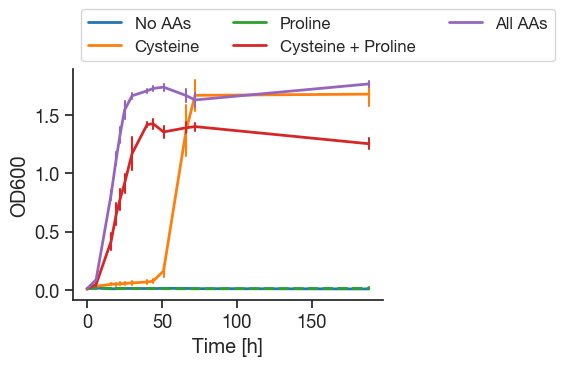

In [423]:
fig, ax = plt.subplots(1, figsize = (4, 3))
sns.lineplot(data = df_Ml_vitamins_AA.loc[~Ml_AA_idx], x = 'Hours', y = 'OD600', hue = 'Medium',
             ax = ax, errorbar= ('sd', 1), err_style='bars',
             palette='tab10', lw = 2, alpha = 1)

ax.lines[4].set_linestyle('--')
# # ax.lines[3].set_zorder(10)
# ax.lines[3].set_linewidth(3)
# ax.lines[0].set_linewidth(3)

sns.move_legend(ax, "lower left", bbox_to_anchor=(0, 1), ncol=3, fontsize = 12, title = None)#, title=None, frameon=False)
sns.despine()
# plt.yscale('log')
# plt.subplots_adjust(right=0.8)
plt.xlabel('Time [h]') 
plt.savefig(figure_folder / "1A_ml_auxotrophy_screen_AAs.pdf", bbox_inches='tight')


In [404]:
medium_map = {
    'MM- + AAs': 'No vitamins',
    'MM- + AAs + Thiamine': 'Thiamine',
    'MM- + AAs + Biotin': 'Biotin',
    'MM- + AAs + Biotin + Thiamine': 'Biotin + Thiamine',
}
df_Ml_vitamins_AA.Medium = df_Ml_vitamins_AA.Medium.map(medium_map)

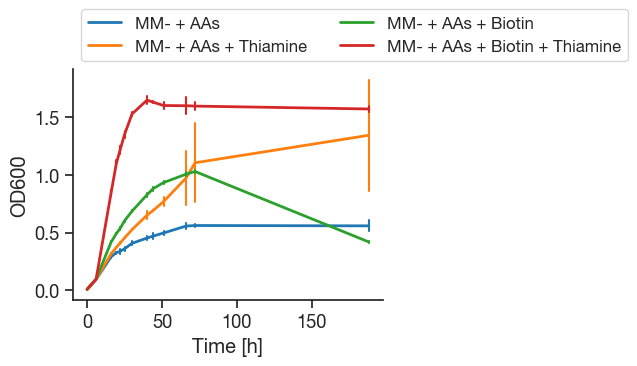

In [420]:
fig, ax = plt.subplots(1, figsize = (4, 3))
sns.lineplot(data = df_Ml_vitamins_AA.loc[Ml_AA_idx], x = 'Hours', y = 'OD600', hue = 'Medium',
             ax = ax, errorbar= ('sd', 1), err_style='bars',
             palette='tab10', lw = 2, alpha = 1)
sns.move_legend(ax, "lower left", bbox_to_anchor=(0, 1), ncol=2, fontsize = 12, title = None)#, title=None, frameon=False      
sns.despine()
# plt.yscale('log')
ax.set_xlabel('Time [h]')
plt.savefig(figure_folder / "1A_ml_auxotrophy_screen_vitamins.pdf", bbox_inches='tight')


Plot vitamin annotations

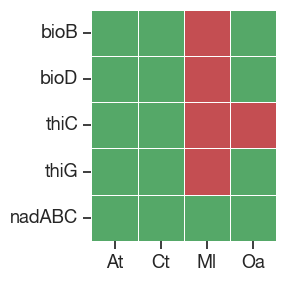

In [385]:
genome_data = [
    # ['bioA', True, True, False, True],
    ['bioB', True, True, False, True],
    ['bioD', True, True, False, True],
    # ['']
    ['thiC', True, True, False, False],
    # ['thiE', True, True, True, True],
    ['thiG', True, True, False, True],
    ['nadABC', True, True, True, True],
    # ['nadB', True, True, True, True],
    # ['nadC', True, True, True, True],
    
]
genome_df = pd.DataFrame(genome_data, columns = ['gene', 'At', 'Ct', 'Ml', 'Oa'])

fig, ax = plt.subplots(1, figsize = (3, 3))

l = sns.heatmap(data = genome_df.set_index('gene'), cmap = ['C3', 'C2'], cbar = False, linewidths=0.5, linecolor='w', square=True, ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), style='italic', rotation=0)
plt.ylabel('')
plt.savefig(figure_folder / "1A_vitamin_auxotrophy_genome_annotations.pdf", bbox_inches='tight')